# 18 — Análisis de una liga (Premier League): plantillas, porteros, impacto en cancha y fantasy

Hay **un notebook por liga** (`18_analisis_liga_<liga>.ipynb`), todos con el mismo código: solo cambian el parámetro
`LIGA` (primera celda de código) y los textos de interpretación, que se escriben después de ver los resultados de
cada liga. Las figuras se guardan con el nombre de la liga en `output/figures/ligas/`, así que no se pisan. La misma
lógica alimenta la página web del análisis (`scripts/export_analisis_liga.py`).

**Datos**: el dataset unificado de la Fase 19 — tabla estándar + `playingtime` + `keepers` de FBref, 16 temporadas
(2010-11 a 2025-26). Se usa en dos niveles:

- **jugador-equipo-temporada** (`filas`) para todo lo que es de un *equipo*: si un jugador se fue a mitad de
  temporada, sus minutos cuentan para cada uno de sus dos equipos;
- **jugador-temporada** (`jt`) para todo lo que es de un *jugador*.

**Secciones**

1. **Plantillas y rotación** — cuántos jugadores usa cada equipo, qué tan concentrados están los minutos, edad y
   extranjeros, temporada por temporada.
2. **Porteros** — % de paradas, porterías a cero y goles recibidos, de la liga y de cada portero.
3. **Impacto en cancha** — ¿qué dicen el +/− y el "con/sin él" de un jugador? (solo desde 2014-15).
4. **Fantasy y dependencia** — cuánto depende cada equipo de su goleador y de su mejor jugador fantasy.

**Lo que conviene recordar al leer**: una celda vacía es "FBref no tiene el dato" (no cero). En esta liga-temporada
pueden faltar datos según la época — el diccionario `data/processed/jugadores_temporada_2010_2026_diccionario.csv`
dice desde cuándo existe cada columna. Toda la lógica está en `futbol_bd/liga.py` (probada en `tests/test_liga.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
from futbol_bd import estilo, fantasy, liga, plantillas

# ======================================================================================================================
LIGA = "Premier League"
# ======================================================================================================================

SLUG = LIGA.lower().replace(" ", "_")
FIGURAS = RAIZ / "output" / "figures" / "ligas"
FIGURAS.mkdir(parents=True, exist_ok=True)
estilo.aplicar()
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

## 0. Los datos de la liga

Se construyen las dos tablas con las funciones del paquete (las mismas que generan el CSV unificado) y se agrega el
resumen por equipo-temporada (`liga.resumen_equipos`). Antes de analizar nada, un control de calidad: cada equipo debe
sumar ≈ partidos × 990 minutos (11 jugadores × 90 minutos por partido; un poco menos si hubo expulsiones). Si faltaran
jugadores en el scrapeo, este cociente quedaría claramente por debajo de 1.

In [2]:
filas = plantillas.unir_tablas_extra(plantillas.limpiar_panel(plantillas.cargar_panel_crudo()))
jt = fantasy.puntos_fantasy(plantillas.agregar_por_temporada(filas))
# Percentil fantasy dentro de liga-temporada-posición (900+ minutos), como en el notebook 17.
jt["pct_pts_jornada"] = fantasy.percentil_en_grupo(jt, "pts_por_jornada")
filas, jt = filas[filas["league"] == LIGA], jt[jt["league"] == LIGA]
equipos = liga.resumen_equipos(filas, LIGA)
TEMPORADAS = sorted(equipos["temporada_inicio"].unique())

control = equipos.assign(cobertura_minutos=equipos["minutos"] / (equipos["pj"] * 990)).groupby("season").agg(
    equipos=("team_id", "size"), partidos_por_equipo=("pj", "median"), jugadores=("jugadores_usados", "sum"),
    cobertura_minutos_min=("cobertura_minutos", "min"), cobertura_minutos_mediana=("cobertura_minutos", "median"))
print(f"{LIGA}: {len(jt):,} jugador-temporadas, {jt['id_jugador'].nunique():,} jugadores, "
      f"{equipos['team_id'].nunique()} equipos distintos en {len(TEMPORADAS)} temporadas")
control.round(3)

Premier League: 8,574 jugador-temporadas, 2,778 jugadores, 41 equipos distintos en 16 temporadas


,equipos,partidos_por_equipo,jugadores,cobertura_minutos_min,cobertura_minutos_mediana
season,,,,,
2010-2011,20,38.0,563,0.995,0.998
2011-2012,20,38.0,561,0.970,0.998
2012-2013,20,38.0,537,0.996,0.998
2013-2014,20,38.0,561,0.994,0.999
2014-2015,20,38.0,549,0.995,0.998
2015-2016,20,38.0,561,0.995,0.998
2016-2017,20,38.0,543,0.995,0.999
2017-2018,20,38.0,529,0.996,0.999
2018-2019,20,38.0,508,0.994,0.998


Control superado: cada equipo suma entre el 97% y el 99.9% de los minutos teóricos (la mediana, 99.8%). Hay 20
equipos y 38 partidos por equipo en las 16 temporadas; la única rareza es 2011-12, donde los resultados reconstruidos
con los porteros dan 37 partidos al QPR y 39 al Chelsea (probablemente un cambio de portero a mitad de partido). En
total, 8,574 jugador-temporadas de 2,778 jugadores en 41 clubes distintos (los ascensos y descensos hacen que pasen
muchos más clubes que en la Liga MX).

## 1. Plantillas y rotación

Cuatro medidas por equipo-temporada (definidas en `liga.resumen_equipos`):

- **jugadores usados**: cuántos jugadores tuvieron minutos;
- **jugadores para el 80% de los minutos**: concentración. Con un once fijo serían ~11-12; si el técnico rota, más.
  Es más robusta que "jugadores usados", que sube con cualquier debutante de 5 minutos;
- **edad ponderada por minutos**: la edad de *quien juega*, no la de la lista;
- **% de minutos de extranjeros** (nacionalidad deportiva según FBref, ver `liga.NACIONALES`).

La figura muestra, por temporada, la **mediana** de los equipos (línea) y el rango donde está la mitad central de los
equipos (banda, percentiles 25-75). Mediana y no promedio: un equipo con una temporada rara no mueve la tendencia.

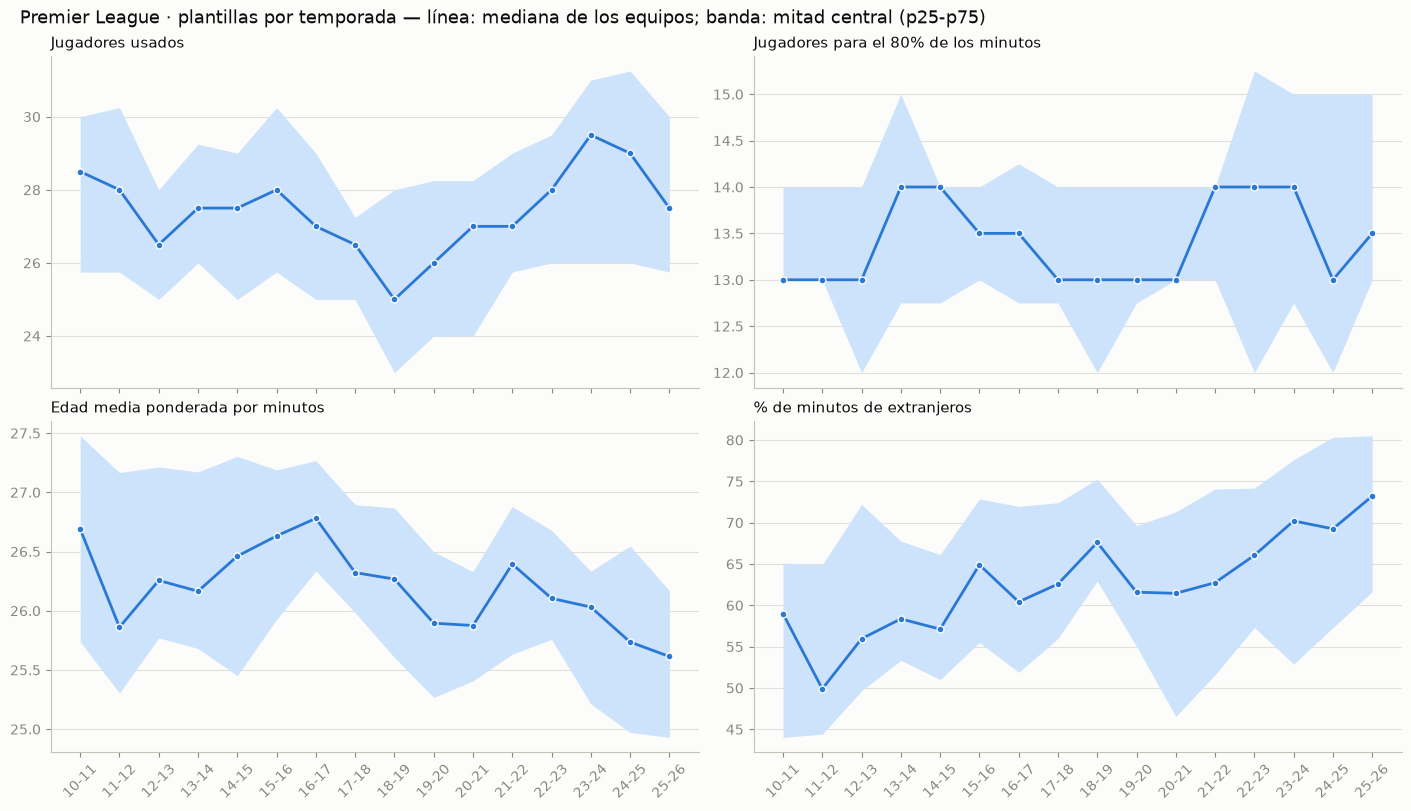

In [3]:
metricas = {"jugadores_usados": "Jugadores usados", "jugadores_80pct": "Jugadores para el 80% de los minutos",
            "edad_ponderada": "Edad media ponderada por minutos", "pct_min_extranjeros": "% de minutos de extranjeros"}
tendencia = liga.tendencia_liga(equipos, list(metricas))

fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs.ravel(), metricas.items()):
    ax.fill_between(TEMPORADAS, tendencia[("p25", col)], tendencia[("p75", col)], color=estilo.AZUL_CLARO, linewidth=0)
    ax.plot(TEMPORADAS, tendencia[("mediana", col)], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
for ax in axs[1]:
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · plantillas por temporada — línea: mediana de los equipos; banda: mitad central (p25-p75)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_plantillas.png", dpi=150)
plt.show()

Diferencias claras con la Liga MX:

- **La rotación no creció.** La mediana de jugadores usados se mueve entre 25 y 29.5 sin tendencia, y los jugadores
  necesarios para el 80% de los minutos entre 13 y 14 en todo el periodo: los cinco cambios no cambiaron cuántos
  jugadores se reparten el grueso de los minutos.
- **Cada vez más extranjeros.** Los minutos de jugadores de fuera del Reino Unido pasaron del 50-59% (2010-14) al
  **73%** en 2025-26, casi sin retrocesos.
- **Más jóvenes.** La edad de quien juega bajó de 26.7 a 25.6 años, y los minutos de jugadores de 21 años o menos
  subieron del 6-9% al 10.6-12.7% en las últimas tres temporadas.

In [4]:
# Los extremos de todo el periodo: los equipos que más rotaron (más jugadores para cubrir el 80% de los minutos) y los
# que menos. Se muestra también el resultado (puntos por partido) para ver si rotar se asocia con ganar o perder.
columnas = ["season", "equipo", "jugadores_usados", "jugadores_80pct", "edad_ponderada", "pct_min_extranjeros", "ppg"]
print("Más rotación:")
display(equipos.nlargest(6, "jugadores_80pct")[columnas].round(1))
print("Menos rotación:")
display(equipos.nsmallest(6, "jugadores_80pct")[columnas].round(1))
rho = spearmanr(equipos["jugadores_80pct"], equipos["ppg"], nan_policy="omit").statistic
print(f"Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): {rho:.2f}")

Más rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
51,2012-2013,QPR,30,18,27.6,62.1,0.7
79,2013-2014,Fulham,39,18,28.4,64.9,0.8
255,2022-2023,Chelsea,32,18,25.8,67.3,1.2
6,2010-2011,West Ham,35,17,27.3,44.2,0.9
52,2012-2013,Reading,28,17,26.6,72.0,0.7
136,2016-2017,Hull City,28,17,26.8,50.5,0.9


Menos rotación:


,season,equipo,jugadores_usados,jugadores_80pct,edad_ponderada,pct_min_extranjeros,ppg
114,2015-2016,Leicester City,23,10,27.2,65.8,2.1
170,2018-2019,Wolves,21,10,25.6,80.7,1.5
38,2011-2012,Swansea City,25,11,24.7,29.2,1.2
91,2014-2015,Burnley,24,11,26.6,10.7,0.9
97,2014-2015,Chelsea,25,11,26.4,82.5,2.3
106,2015-2016,Tottenham,24,11,24.1,53.8,1.8


Rotación vs puntos por partido (Spearman, todos los equipo-temporadas): -0.29


Rotar también se asocia con perder, aunque menos que en la Liga MX (**−0.29** contra −0.47). Los dos casos extremos
lo ilustran: el **Leicester 2015-16** repartió el 80% de sus minutos entre solo 10 jugadores y fue campeón (2.1
puntos por partido), igual que el Chelsea 2014-15 con 11 (2.3). En el otro extremo, QPR 2012-13 y Fulham 2013-14
necesitaron 18 jugadores y descendieron (0.7-0.8 puntos por partido). La excepción moderna es el Chelsea 2022-23: 18
jugadores y 1.2 puntos por partido.

## 2. Porteros

Primero la liga completa: % de paradas (paradas / tiros a puerta recibidos), goles recibidos por partido y % de
partidos con portería a cero, sumando a todos los porteros antes de dividir (una tasa de la liga, no el promedio de
las tasas de cada portero). Después, cada portero en toda su carrera en la liga.

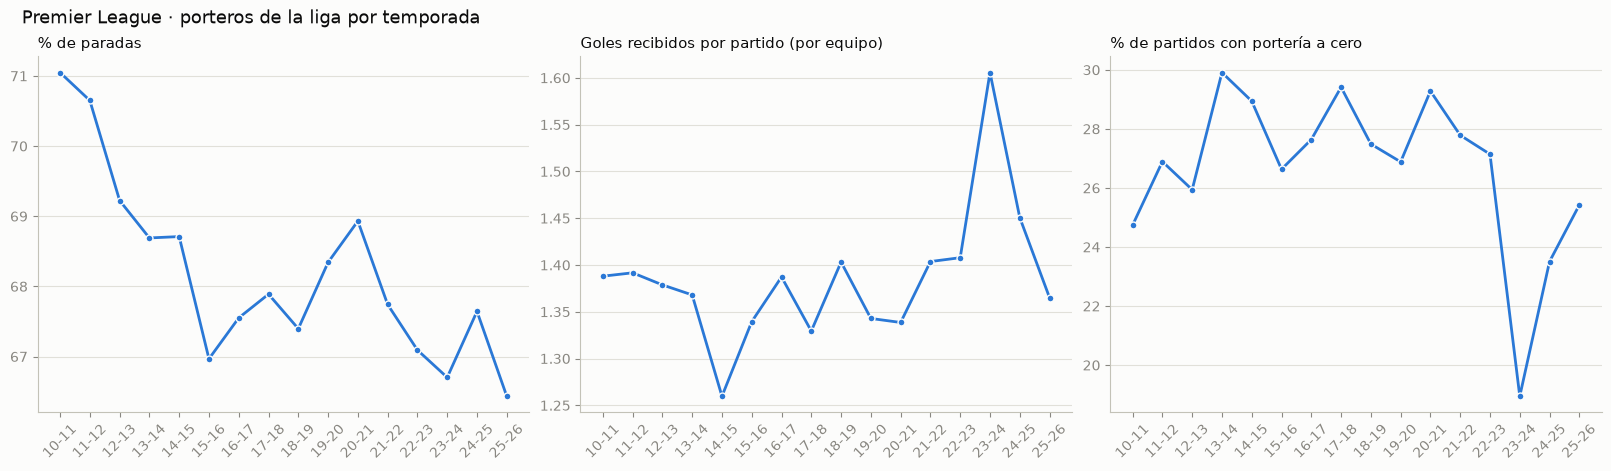

In [5]:
lp = liga.porteros_liga(jt, LIGA).reindex(TEMPORADAS)
paneles = {"pct_paradas": "% de paradas", "goles_recibidos_por_partido": "Goles recibidos por partido (por equipo)",
           "pct_porterias_cero": "% de partidos con portería a cero"}
fig, axs = plt.subplots(1, 3, figsize=(16, 4.6), sharex=True, constrained_layout=True)
for ax, (col, titulo) in zip(axs, paneles.items()):
    # Una temporada sin dato queda como hueco en la línea (no se une con la siguiente como si hubiera dato).
    ax.plot(TEMPORADAS, lp[col], color=estilo.AZUL, linewidth=2, marker="o", markersize=5,
            markeredgecolor=estilo.SUPERFICIE)
    faltan = [t for t in TEMPORADAS if pd.isna(lp.loc[t, col])]
    for t in faltan:
        ax.annotate("sin dato", (t, ax.get_ylim()[0]), xytext=(0, 4), textcoords="offset points", ha="center",
                    fontsize=8, color=estilo.TENUE)
    ax.set_title(titulo)
    estilo.rejilla_y(ax)
    estilo.etiquetas_temporada(ax, TEMPORADAS)
fig.suptitle(f"{LIGA} · porteros de la liga por temporada", x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_porteros_liga.png", dpi=150)
plt.show()

- **El % de paradas también cae**, como en la Liga MX: de 71% en 2010-11 a 66% en 2025-26.
- **Goles recibidos por partido**: estables entre 1.26 y 1.45 durante todo el periodo, salvo **2023-24 (1.61)**, la
  temporada más goleadora; esa misma temporada tuvo el menor % de porterías a cero (19%).
- **Porterías a cero**: entre 23.5% y 30% en el resto de las temporadas.
- A diferencia de la Liga MX, no hay temporadas sin dato de paradas.

In [6]:
# Carreras completas en la liga (mínimo 9,000 minutos ≈ 100 partidos): el % de paradas de toda la carrera pondera cada
# temporada por los tiros que recibió.
carreras = liga.carrera_porteros(jt, LIGA, min_minutos=9000)
columnas = ["portero", "equipos", "desde", "hasta", "partidos", "pct_paradas", "pct_porterias_cero", "goles_recibidos_90"]
display(carreras[columnas].head(12).round(2))

# ¿El % de paradas es del portero o de su defensa? Correlación entre una temporada y la siguiente (1,500+ minutos).
porteros_jt = jt[jt["gk_games"].notna()]
r_paradas, n_paradas, _ = liga.estabilidad(porteros_jt, "gk_save_pct", minutos="gk_minutes")
r_cero, n_cero, _ = liga.estabilidad(porteros_jt, "gk_clean_sheets_pct", minutos="gk_minutes")
print(f"Estabilidad año a año — % de paradas: r = {r_paradas:.2f} ({n_paradas} pares); "
      f"% porterías a cero: r = {r_cero:.2f} ({n_cero} pares)")

,portero,equipos,desde,hasta,partidos,pct_paradas,pct_porterias_cero,goles_recibidos_90
id_jugador,,,,,,,,
71672fa0,Petr Čech,Chelsea / Arsenal,2010,2018,259.0,74.41,39.00,1.01
98ea5115,David Raya,Brentford / Arsenal,2021,2025,169.0,72.76,39.05,0.93
4b40d9ca,Nick Pope,Burnley / Newcastle,2017,2025,248.0,72.69,32.66,1.18
7ba6d84e,David de Gea,Manchester Utd,2011,2022,415.0,72.25,35.66,1.08
da409c6f,Mark Schwarzer,Fulham / Chelsea / Leicester City,2010,2014,107.0,72.20,29.91,1.35
7a2e46a8,Alisson,Liverpool,2018,2025,255.0,72.07,40.39,0.92
340d2a24,Jussi Jääskeläinen,Bolton / West Ham,2010,2014,110.0,71.92,24.55,1.51
1bebde9d,Michel Vorm,Swansea City / Tottenham,2011,2018,102.0,71.86,30.39,1.30
f76e6b4e,Adrián,West Ham / Liverpool,2013,2020,139.0,70.87,27.34,1.35


Estabilidad año a año — % de paradas: r = 0.30 (197 pares); % porterías a cero: r = 0.36 (197 pares)


Entre los 45 porteros con 100+ partidos, **Petr Čech** (Chelsea y Arsenal, 2010-2018) tiene el mejor % de paradas
(74.4%), pero **Ederson** tiene el mejor % de porterías a cero (44.6%) y la menor cantidad de goles recibidos por 90
(0.79), seguido de Alisson. Las métricas no coinciden porque miden cosas distintas: el % de paradas es más del
portero; las porterías a cero y los goles recibidos dependen mucho de la defensa (y el Manchester City y el
Liverpool concedieron muy pocos tiros).

Estabilidad año a año: % de paradas r = 0.30, igual que en la Liga MX; % de porterías a cero r = **0.36**, más alto
que en la Liga MX (0.22). En la Premier las diferencias entre equipos son grandes y se sostienen de un año a otro, y
eso se nota en las porterías a cero.

In [7]:
# La última temporada, porteros con 900+ minutos. Y un control de calidad: goles recibidos según la tabla de porteros
# vs. goles recibidos por su equipo con él en cancha (onGA). Deberían coincidir; donde no, FBref se contradice.
ultima = jt[(jt["temporada_inicio"] == TEMPORADAS[-1]) & (jt["gk_minutes"] >= 900)]
display(ultima.sort_values("gk_save_pct", ascending=False)[
    ["player", "equipo_principal", "gk_games", "gk_save_pct", "gk_clean_sheets", "gk_goals_against",
     "on_goals_against"]].round(1))

por_temporada = liga.desacuerdo_goles_porteros(porteros_jt)
print(f"Porteros-temporada con ambos datos: {por_temporada['porteros'].sum()}; no coinciden: "
      f"{por_temporada['no_coinciden'].sum()}. Por temporada:")
display(por_temporada.set_index("temporada_inicio").T)
con_ambos = porteros_jt[porteros_jt["on_goals_against"].notna()]
difiere = con_ambos[con_ambos["gk_goals_against"] != con_ambos["on_goals_against"]]
print("Los de mayor diferencia:")
display(difiere.assign(diferencia=difiere["on_goals_against"] - difiere["gk_goals_against"])
        .reindex(columns=["player", "season", "equipo_principal", "gk_games", "gk_goals_against", "on_goals_against",
                          "diferencia"])
        .sort_values("diferencia", key=abs, ascending=False).head(5))

,player,equipo_principal,gk_games,gk_save_pct,gk_clean_sheets,gk_goals_against,on_goals_against
49914,Emiliano Martínez,Aston Villa,32.0,70.9,8.0,39.0,39.0
49947,Gianluigi Donnarumma,Manchester City,34.0,70.8,15.0,29.0,29.0
50132,Matz Sels,Nottingham,31.0,70.5,7.0,39.0,39.0
50220,Robin Roefs,Sunderland,35.0,70.1,10.0,46.0,46.0
50166,Nick Pope,Newcastle,27.0,70.1,7.0,38.0,38.0
50060,Karl Darlow,Leeds United,22.0,70.0,5.0,27.0,27.0
49888,David Raya,Arsenal,37.0,68.6,19.0,26.0,26.0
49825,Bart Verbruggen,Brighton,38.0,68.2,10.0,46.0,46.0
49854,Caoimhín Kelleher,Brentford,37.0,68.2,10.0,49.0,49.0
49795,Alphonse Areola,West Ham,20.0,67.3,0.0,37.0,37.0


Porteros-temporada con ambos datos: 492; no coinciden: 4. Por temporada:


temporada_inicio,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
no_coinciden,0,0,0,1,0,0,0,0,0,1,1,1
porteros,44,47,42,38,38,37,41,42,39,40,44,40


Los de mayor diferencia:


,player,season,equipo_principal,gk_games,gk_goals_against,on_goals_against,diferencia
49371,Emiliano Martínez,2024-2025,Aston Villa,37.0,47.0,45.0,-2.0
50219,Robert Sánchez,2025-2026,Chelsea,35.0,49.0,47.0,-2.0
45736,Jonas Lössl,2017-2018,Huddersfield,38.0,57.0,58.0,1.0
49024,Matt Turner,2023-2024,Nottingham,17.0,28.0,29.0,1.0


En 2025-26 encabezan Emiliano Martínez (Aston Villa, 70.9%), Gianluigi Donnarumma (Manchester City, 70.8% y 15
porterías a cero) y Matz Sels (Nottingham, 70.5%); los últimos con 900+ minutos son Aaron Ramsdale (58.5%) y Lucas
Perri (56.7%).

**Calidad de datos**: en la Premier las dos tablas de FBref casi siempre coinciden (0 o 1 portero con distinto número
de goles recibidos por temporada), a diferencia de la Liga MX en 2014-16.

## 3. Impacto en cancha

FBref publica, desde 2014-15, dos medidas de "qué pasa cuando el jugador está en la cancha":

- **on-off** (`plus_minus_wowy`): goles netos de su equipo por 90 minutos con él en cancha, menos sin él;
- **puntos por partido con él** (`points_per_game`). Aquí se compara con los puntos por partido de su equipo en toda
  la temporada: `ppg_extra` = puntos con él − puntos del equipo (solo jugadores con un solo equipo esa temporada, para
  que la comparación sea limpia).

Son tentadoras como medida de "impacto", pero están muy expuestas a cosas ajenas al jugador: con quién comparte
cancha, contra quién jugó, si solo entra cuando el partido está roto. Antes de usarlas hay que probar si miden algo
**del jugador**: si fuera así, quien sale alto una temporada tendería a salir alto la siguiente. Como referencia de lo
que se ve cuando una medida sí es del jugador, se agrega una métrica individual: goles sin penal por 90 de los
delanteros.

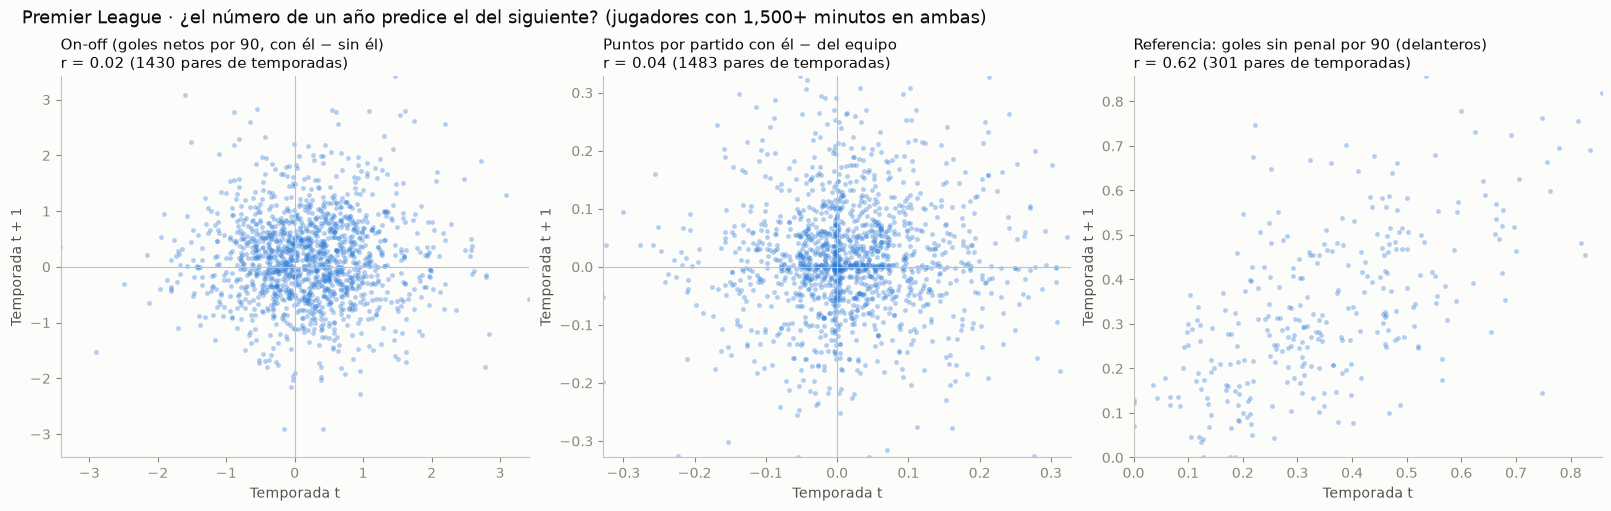

,r,pares
"On-off (goles netos por 90, con él − sin él)",0.02,1430.0
Puntos por partido con él − del equipo,0.04,1483.0
Referencia: goles sin penal por 90 (delanteros),0.62,301.0


In [8]:
# ppg_extra = puntos por partido con él − del equipo; solo jugadores con un equipo en la temporada (ver docstring).
jt = liga.agregar_ppg_extra(jt, equipos)

pruebas = {
    "plus_minus_wowy": ("On-off (goles netos por 90, con él − sin él)", jt),
    "ppg_extra": ("Puntos por partido con él − del equipo", jt),
    "goals_pens_per90": ("Referencia: goles sin penal por 90 (delanteros)", jt[jt["pos_principal"] == "FW"]),
}
fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
resumen_estabilidad = {}
for ax, (col, (titulo, datos)) in zip(axs, pruebas.items()):
    r, n, pares = liga.estabilidad(datos, col, min_minutos=1500)
    resumen_estabilidad[titulo] = {"r": round(r, 2), "pares": n}
    ax.scatter(pares[col], pares[f"{col}_siguiente"], s=12, color=estilo.AZUL, alpha=0.35, linewidths=0)
    lim = np.nanpercentile(np.abs(pares[[col, f"{col}_siguiente"]].to_numpy()), 99)
    if col == "goals_pens_per90":
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    else:
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.axhline(0, color=estilo.EJE, linewidth=0.8); ax.axvline(0, color=estilo.EJE, linewidth=0.8)
    ax.set_title(f"{titulo}\nr = {r:.2f} ({n} pares de temporadas)")
    ax.set_xlabel("Temporada t"); ax.set_ylabel("Temporada t + 1")
fig.suptitle(f"{LIGA} · ¿el número de un año predice el del siguiente? (jugadores con 1,500+ minutos en ambas)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_impacto_estabilidad.png", dpi=150)
plt.show()
pd.DataFrame(resumen_estabilidad).T

El mismo resultado que en la Liga MX, con más datos:

| Medida | Correlación año a año |
|---|---|
| On-off (goles netos con él − sin él) | **0.02** (1,430 pares) |
| Puntos por partido con él − del equipo | **0.04** (1,483 pares) |
| Referencia: goles sin penal por 90 (delanteros) | **0.62** (301 pares) |

Tampoco en la Premier el on-off ni los puntos con/sin un jugador de una temporada dicen algo del jugador; la medida
individual de referencia es aún más estable que en la Liga MX (0.62 contra 0.52). No se publica ranking de impacto.

## 4. Fantasy y dependencia

Dos preguntas sobre cómo se reparte la producción dentro de cada equipo:

1. **Dependencia del goleador**: qué parte de los goles del equipo hizo su máximo goleador. ¿Depender de un solo
   jugador se asocia con sumar más o menos puntos?
2. **El mejor jugador fantasy de cada equipo** en la última temporada y qué parte de los puntos fantasy del equipo
   hizo (con el esquema ofensivo del notebook 17; los puntos de un jugador traspasado cuentan para su equipo
   principal).

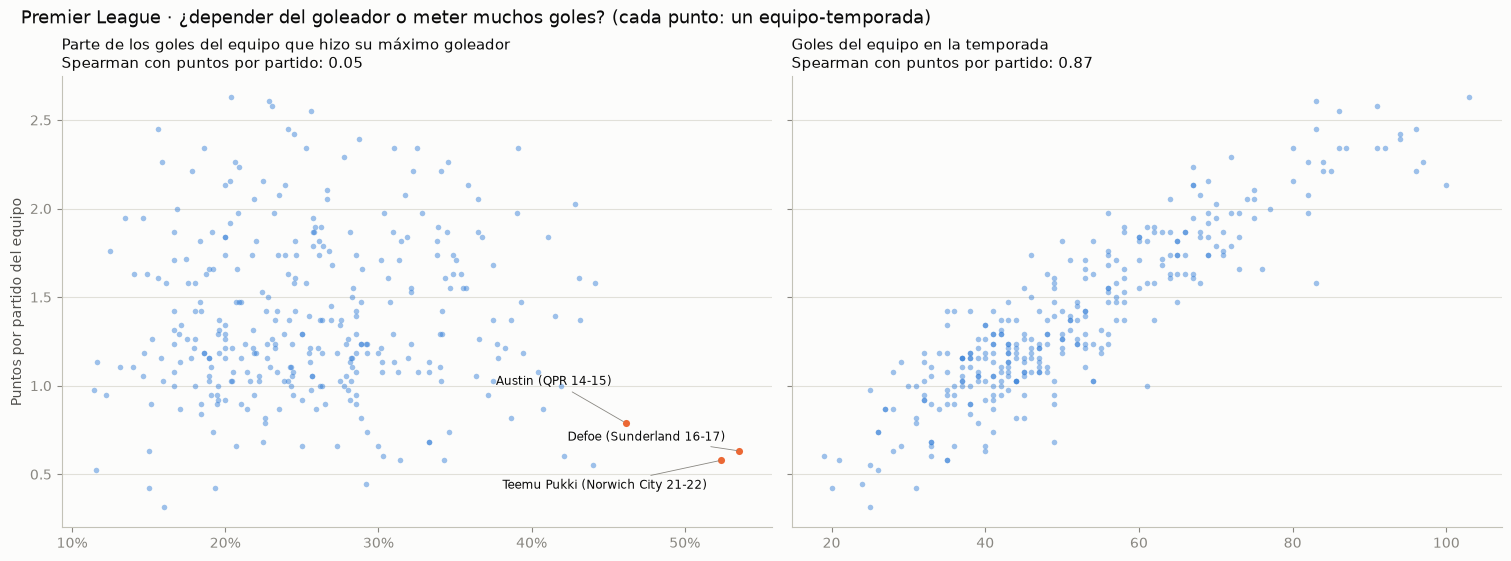

,season,equipo,goleador,goles_goleador,goles,dependencia_goleador,ppg
132,2016-2017,Sunderland,Jermain Defoe,15.0,28.0,0.54,0.63
222,2021-2022,Norwich City,Teemu Pukki,11.0,21.0,0.52,0.58
93,2014-2015,QPR,Charlie Austin,18.0,39.0,0.46,0.79
243,2022-2023,Tottenham,Harry Kane,30.0,68.0,0.44,1.58
182,2019-2020,Norwich City,Teemu Pukki,11.0,25.0,0.44,0.55
185,2019-2020,Southampton,Danny Ings,22.0,51.0,0.43,1.37
138,2016-2017,Everton,Romelu Lukaku,25.0,58.0,0.43,1.61
145,2017-2018,Tottenham,Harry Kane,30.0,70.0,0.43,2.03


Mediana de la dependencia por temporada: {'2010-2011': 0.22, '2011-2012': 0.26, '2012-2013': 0.29, '2013-2014': 0.22, '2014-2015': 0.24, '2015-2016': 0.27, '2016-2017': 0.27, '2017-2018': 0.23, '2018-2019': 0.26, '2019-2020': 0.29, '2020-2021': 0.26, '2021-2022': 0.24, '2022-2023': 0.27, '2023-2024': 0.24, '2024-2025': 0.28, '2025-2026': 0.23}


In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True, constrained_layout=True)
rho_dep = spearmanr(equipos["dependencia_goleador"], equipos["ppg"], nan_policy="omit").statistic
rho_gol = spearmanr(equipos["goles"], equipos["ppg"], nan_policy="omit").statistic
for ax, (col, titulo, rho, fmt) in zip(axs, [
        ("dependencia_goleador", "Parte de los goles del equipo que hizo su máximo goleador", rho_dep, "{:.0%}"),
        ("goles", "Goles del equipo en la temporada", rho_gol, "{:.0f}")]):
    ax.scatter(equipos[col], equipos["ppg"], s=16, color=estilo.AZUL, alpha=0.45, linewidths=0)
    ax.set_title(f"{titulo}\nSpearman con puntos por partido: {rho:.2f}")
    estilo.rejilla_y(ax)
    if col == "dependencia_goleador":
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
        # Se resaltan los 3 equipos más dependientes. Las etiquetas se escalonan en vertical porque dos de ellos tienen
        # exactamente 1.00 punto por partido y quedarían encimadas.
        for k, (_, e) in enumerate(equipos.nlargest(3, col).iterrows()):
            ax.scatter(e[col], e["ppg"], s=44, color=estilo.NARANJA, edgecolors=estilo.SUPERFICIE, linewidths=1.5,
                       zorder=3)
            nombre = e["goleador"] if len(e["goleador"]) <= 12 else e["goleador"].split()[-1]
            ax.annotate(f"{nombre} ({e['equipo']} {e['season'][2:4]}-{e['season'][7:]})", (e[col], e["ppg"]),
                        xytext=(-10, [10, -18, 30][k]), textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=estilo.TINTA,
                        arrowprops=dict(arrowstyle="-", color=estilo.TENUE, linewidth=0.6))
axs[0].set_ylabel("Puntos por partido del equipo")
fig.suptitle(f"{LIGA} · ¿depender del goleador o meter muchos goles? (cada punto: un equipo-temporada)",
             x=0.01, ha="left", fontsize=13, color=estilo.TINTA)
fig.savefig(FIGURAS / f"{SLUG}_dependencia_goleador.png", dpi=150)
plt.show()

display(equipos.nlargest(8, "dependencia_goleador")[
    ["season", "equipo", "goleador", "goles_goleador", "goles", "dependencia_goleador", "ppg"]].round(2))
print("Mediana de la dependencia por temporada:",
      equipos.groupby("season")["dependencia_goleador"].median().round(2).to_dict())

- **Depender del goleador tampoco se asocia con puntos** (0.05); los goles totales del equipo, todavía más que en la
  Liga MX (**0.87** contra 0.78).
- De los seis equipos más dependientes, cuatro descendieron: **Jermain Defoe** hizo el 54% de los goles del
  Sunderland 2016-17 (0.63 puntos por partido) y **Teemu Pukki** el 52% del Norwich 2021-22. Las excepciones son
  **Harry Kane** (44% de los goles del Tottenham 2022-23, 1.58 puntos por partido) y Danny Ings (Southampton 2019-20).
- La dependencia mediana se mueve entre 22% y 29%, sin tendencia (en la Liga MX bajó).

In [10]:
# Mejor jugador fantasy de cada equipo en la última temporada y su parte de los puntos del equipo.
mejores = liga.mejor_fantasy_por_equipo(jt, TEMPORADAS[-1])
mejores[["equipo_principal", "player", "pos_principal", "goals", "assists", "pts_total", "pts_equipo",
         "parte_del_equipo", "pct_pts_jornada"]].round(2)

,equipo_principal,player,pos_principal,goals,assists,pts_total,pts_equipo,parte_del_equipo,pct_pts_jornada
49919,Manchester City,Erling Haaland,FW,27.0,8.0,197.0,1312.0,0.15,100.00
50006,West Ham,Jarrod Bowen,MF,9.0,11.0,150.0,1178.0,0.13,98.03
50154,Nottingham,Morgan Gibbs-White,MF,15.0,4.0,158.0,1246.0,0.13,98.68
49973,Brentford,Igor Thiago,FW,22.0,1.0,157.0,1243.0,0.13,97.67
49845,Manchester Utd,Bruno Fernandes,MF,9.0,21.0,169.0,1366.0,0.12,100.00
49810,Bournemouth,Antoine Semenyo,MF,17.0,4.0,162.0,1369.0,0.12,99.34
50046,Chelsea,João Pedro,FW,15.0,5.0,136.0,1267.0,0.11,93.02
49959,Fulham,Harry Wilson,MF,10.0,7.0,132.0,1252.0,0.11,96.71
50186,Aston Villa,Ollie Watkins,FW,16.0,3.0,139.0,1347.0,0.10,95.35
49899,Leeds United,Dominic Calvert-Lewin,FW,14.0,1.0,119.0,1216.0,0.10,90.70


En 2025-26 el mejor jugador fantasy de cada equipo aporta entre el 7% (Strand Larsen, Wolves) y el 15% (**Erling
Haaland**, 197 puntos, Manchester City) de los puntos fantasy de su equipo. Todos son delanteros o medios; Bruno
Fernandes (Manchester United) es el único entre los mejores cuyo puntaje viene más de asistencias (21) que de goles.

## 5. Conclusiones y cómo ampliar a otra liga

**Premier League, 2010-11 a 2025-26, comparada con la Liga MX:**

1. **Plantillas**: la rotación no creció (13-14 jugadores para el 80% de los minutos en todo el periodo), a
   diferencia de la Liga MX. Los extranjeros pasaron del 50-59% al 73% de los minutos y los equipos son más jóvenes.
   Rotar se asocia con perder (−0.29), menos que en la Liga MX.
2. **Porteros**: el % de paradas cae igual que en la Liga MX (71% → 66%). Čech tiene el mejor % de paradas y
   Ederson las mejores porterías a cero y goles recibidos. Aquí las porterías a cero son más estables (0.36) porque
   las diferencias entre equipos son persistentes. Los datos de FBref son más limpios que en la Liga MX.
3. **Impacto en cancha**: igual de inútil para evaluar jugadores con datos de temporada (0.02 y 0.04).
4. **Dependencia**: tampoco da puntos; lo que cuenta son los goles del equipo (0.87). De los seis equipos más
   dependientes de un goleador, cuatro descendieron.

**Otras ligas**: hay un notebook por liga (`18_analisis_liga_<liga>.ipynb`) con este mismo código; solo cambian
`LIGA` y los textos. La página web del análisis muestra las mismas gráficas para cada liga publicada, más un
explorador de plantillas por equipo y temporada.